# Woody Hayes Dr. Construction Analysis

This notebook is intended to analyze if the lane restrictions on Woody Hayes Dr. starting on March 26, 2026 have impacted metrics for the medical center shuttle.


---

### Background:

On March 26th, 2026, Woody Hayes Dr. between Kenny Rd. and John H Herrick Dr. was reduced from 2 eastbound lanes and 2 westbound lanes with a center median, to 1 lane each direction. This is due to construction occuring on the adjacent lot intended to end in mid June 2026. The following questions intend to be answered by this analysis:

1) Has this lane restriction caused a change in travel time for the med center express shuttle?
2) Are buses 'bunching' due to traffic in the area?
    - This will be defined by close arrival times of multiple busses, or rather how spread out the busses appear to be in terms of arrival time.

### Relevant Information:

Busstate data for this analysis was pulled on 4/29/2026 and is stored at the following file path:

`../WMC_Dashboard/analysis_data/woody_hayes/`

This includes busstate data from February - April 2026

---

### Setup:

In [9]:
# Lane restriction was implemented at some point on 3/36/2026
# Going to pull in data and split around this date for before and after analysis

# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import importlib

UH_ID = 401
DOAN_ID = 37
CARMACK_2_ID = 403

In [2]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/woody_hayes"

# month and date dict
timeframe_dict = {
    # 'JAN': 2026,
    'FEB': 2026,
    'MAR': 2026,
    'APR': 2026
}

# loop through and concat to once single df
df = pd.DataFrame()
for month, year in timeframe_dict.items():
    df = pd.concat([df, mcd.process_mc_busstate(year=year, month=month, current_dir=repo_dir)], ignore_index=True)

# This should only have to be run once per session. ~9 minutes to run

In [5]:
# split into before and after timeframes with equal number of days on either side
# not inclusive of 3/26/2026 as the lane restriction could have been implemented at any point during that day
before_df = df[(df['DATE'] >= '2026-02-25') & (df['DATE'] < '2026-03-26')] # 21 business days 2/25 - 3/25
after_df = df[(df['DATE'] > '2026-03-26') & (df['DATE'] <= '2026-04-24')] # 21 business days 3/27 - 4/24

In [6]:
print(f'Before lane restriction: {len(before_df)} records')
print(f'After lane restriction: {len(after_df)} records') # even out records

Before lane restriction: 34574 records
After lane restriction: 34779 records


Records are roughly even

---

### 1) Has the lane restriction led to a change in travel times and WHEN did it increase?

Specifically in the ~3-5pm hour

In [142]:
# import travel_time module as initial check
from modules import travel_time 

before_travel_time = travel_time.create_travel_time(before_df)
after_travel_time = travel_time.create_travel_time(after_df)

print("Before lane restriction travel time stats:")
display(before_travel_time)

print("After lane restriction travel time stats:")
display(after_travel_time)

Before lane restriction travel time stats:


,TIME,LOOPS,CARMACK 2 - UH/DOAN,UH/DOAN - CARMACK 2
0,5:30-7a,803,7.9,6.5
1,7-10a,1025,10.8,7.0
2,10a-4p,1264,10.3,6.7
3,4-7p,1027,10.2,6.5
4,7p-12a,1163,10.0,5.8
5,12-5a,403,9.5,5.4


After lane restriction travel time stats:


,TIME,LOOPS,CARMACK 2 - UH/DOAN,UH/DOAN - CARMACK 2
0,5:30-7a,808,7.9,6.4
1,7-10a,991,10.8,7.0
2,10a-4p,1280,10.2,7.0
3,4-7p,1022,10.3,7.9
4,7p-12a,1231,10.0,5.9
5,12-5a,401,9.7,5.5


Initial look given my existing module. Travel time appear to be about the same with a decent increase in the travel time specifically in the 4pm-7pm outbound timeframe. The 10a-4p timeframe also has a slight increase in time.


---

Isolating the outbound travel, timedelta of Doan Hall departure to Carmack 2 arrival

**Statistical Testing**

`H0`: mean travel time before lane closure = mean travel time after lane closure

`HA`: Mean travel time after > mean travel time before
- This is one sided since we care specifically about increases here due to roadway congestion

In [143]:
# df already has hour buckets

before_df.info() # 37 is Doan Hall, 401 is Carmack 2

# specifically want the travel time from departure of Doan Hall to arrival at Carmack 2
# before_outbound_df = before_df

<class 'pandas.DataFrame'>
Index: 34574 entries, 1227 to 67644
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   BUS_ID               34574 non-null  int64          
 1   DATE                 34574 non-null  datetime64[us] 
 2   COUNT                34574 non-null  int64          
 3   STOP_ID              34574 non-null  int64          
 4   BOARDINGS            34574 non-null  float64        
 5   ALIGHTINGS           34574 non-null  float64        
 6   LOAD                 34574 non-null  int64          
 7   RUN_ID               34574 non-null  float64        
 8   DEST                 34574 non-null  str            
 9   ARRIVAL              34574 non-null  datetime64[us] 
 10  DEPARTURE            34574 non-null  datetime64[us] 
 11  DWELL                34574 non-null  timedelta64[us]
 12  HOUR                 34574 non-null  int32          
 13  MINUTE               34574 no

In [ ]:
before_outbound_df = before_df[(before_df['STOP_ID'] == DOAN_ID) | (before_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
before_outbound_df = before_outbound_df.drop(columns=['LOAD', 'DEST']) 

# sort by bus and time
before_outbound_df = before_outbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (before_outbound_df['BUS_ID'] == before_outbound_df['BUS_ID'].shift(1))
    & (before_outbound_df['DATE'] == before_outbound_df['DATE'].shift(1))
    & (before_outbound_df['RUN_ID'] == before_outbound_df['RUN_ID'].shift(1))
    & (before_outbound_df['STOP_ID'].shift(1) == DOAN_ID) # only calculate run time if previous record was Doan Hall
)

before_outbound_df['RUN_TIME'] = np.where(
    same_trip,
    (before_outbound_df['ARRIVAL'] - before_outbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 20 minutes 
before_outbound_df = before_outbound_df[(before_outbound_df['RUN_TIME'] >= 3) & (before_outbound_df['RUN_TIME'] <= 20)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 20 is likely an outlier

# drop OB rows only want outbound trips
before_outbound_df = before_outbound_df[before_outbound_df['STOP_ID'] == CARMACK_2_ID]

display(before_outbound_df.head(3))


#----------------------------------
# Repeat for after lane restriction
after_outbound_df = after_df[(after_df['STOP_ID'] == DOAN_ID) | (after_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
after_outbound_df = after_outbound_df.drop(columns=['LOAD', 'DEST']) 

# sort by bus and time
after_outbound_df = after_outbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (after_outbound_df['BUS_ID'] == after_outbound_df['BUS_ID'].shift(1))
    & (after_outbound_df['DATE'] == after_outbound_df['DATE'].shift(1))
    & (after_outbound_df['RUN_ID'] == after_outbound_df['RUN_ID'].shift(1))
    & (after_outbound_df['STOP_ID'].shift(1) == DOAN_ID) # only calculate run time if previous record was Doan Hall
)

after_outbound_df['RUN_TIME'] = np.where(
    same_trip,
    (after_outbound_df['ARRIVAL'] - after_outbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 30
after_outbound_df = after_outbound_df[(after_outbound_df['RUN_TIME'] >= 3) & (after_outbound_df['RUN_TIME'] <= 20)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 20 is likely an outlier

# drop OB rows only want outbound trips
after_outbound_df = after_outbound_df[after_outbound_df['STOP_ID'] == CARMACK_2_ID]

display(after_outbound_df.head(3))


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
2,2104,2026-02-25,21191,403,7.0,1.0,1501.0,1900-01-01 05:11:36,1900-01-01 05:14:35,0 days 00:02:59,5,11,IB,2026-02-25 05:11:36,5.533333
4,2104,2026-02-25,21195,403,22.0,1.0,1501.0,1900-01-01 05:31:15,1900-01-01 05:35:29,0 days 00:04:14,5,31,IB,2026-02-25 05:31:15,5.166667
6,2104,2026-02-25,21199,403,4.0,0.0,1501.0,1900-01-01 05:50:36,1900-01-01 05:52:36,0 days 00:02:00,5,50,IB,2026-02-25 05:50:36,5.916667


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
3,2501,2026-03-27,26681,403,6.0,0.0,1501.0,1900-01-01 05:14:06,1900-01-01 05:14:51,0 days 00:00:45,5,14,IB,2026-03-27 05:14:06,4.800000
5,2501,2026-03-27,26685,403,11.0,1.0,1501.0,1900-01-01 05:32:02,1900-01-01 05:33:55,0 days 00:01:53,5,32,IB,2026-03-27 05:32:02,6.983333
7,2501,2026-03-27,26689,403,4.0,2.0,1501.0,1900-01-01 05:50:22,1900-01-01 05:52:57,0 days 00:02:35,5,50,IB,2026-03-27 05:50:22,5.416667


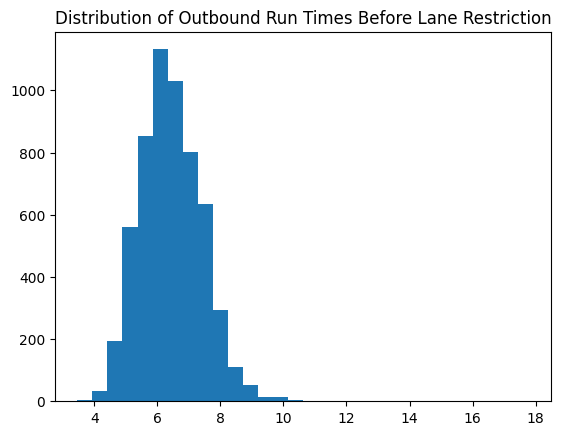

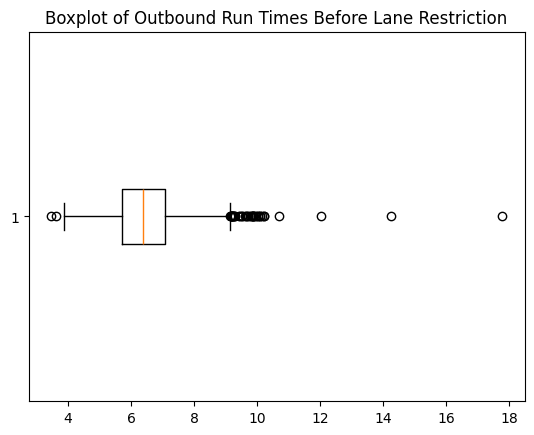

In [145]:
# determine the level of skew in the outbound run_time data
plt.hist(before_outbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Outbound Run Times Before Lane Restriction')
plt.show()

plt.boxplot(before_outbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Outbound Run Times Before Lane Restriction')
plt.show()

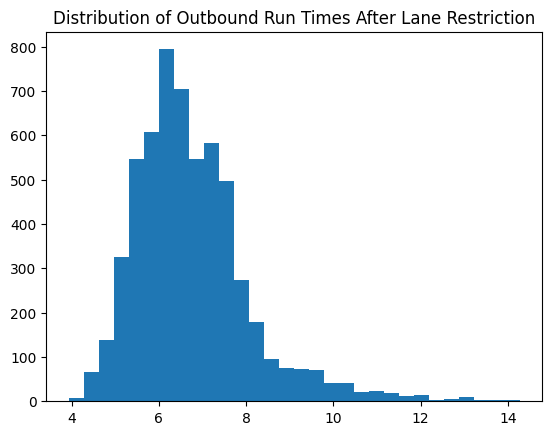

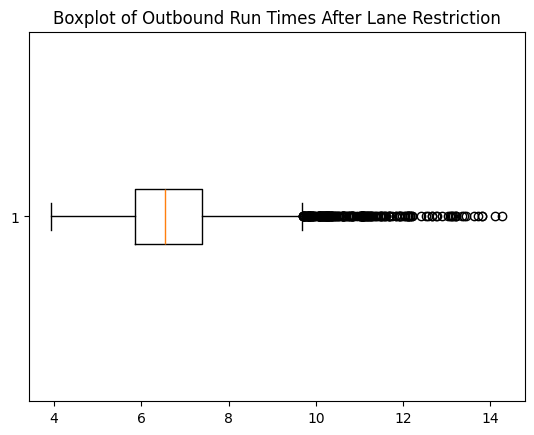

In [146]:
# determine the level of skew in the outbound run_time data
plt.hist(after_outbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Outbound Run Times After Lane Restriction')
plt.show()

plt.boxplot(after_outbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Outbound Run Times After Lane Restriction')
plt.show()


---

### Notes: 

- The data has not been transformed with a log, but maintains right skew.
- Attempt a single regression model with categorical hour bins. This avoids the potential small sample instability per hour with an individual Mann-Whitney test for each hour. This allows for a much cleaner interpretation and more statistical power.
- Model will estimate the following:
    1) Average shift after construction 
    2) Hourly fixed effects, normal daily patterns
    3) Interaction between the 2, how much did the travel time change in this specific hour after the lane restriction was put in place?


RUN_TIMEi​=β0​+β1​(after)+β2​(hour effects)+β3​(after × hour)+ϵi​

In [147]:
import statsmodels.formula.api as smf

# combine before and after data for regression analysis
outbound_df = pd.concat([before_outbound_df, after_outbound_df], ignore_index=True)
outbound_df['post_period'] = (outbound_df['DATE'] >= '2026-03-26').astype(int) # binary variable for before/after lane restriction

outbound_model = smf.ols(
formula='RUN_TIME ~ post_period + C(HOUR) + post_period:C(HOUR)',
data=outbound_df
).fit()

print(outbound_model.summary())

                            OLS Regression Results                            
Dep. Variable:               RUN_TIME   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     163.9
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:52:56   Log-Likelihood:                -15293.
No. Observations:               11511   AIC:                         3.068e+04
Df Residuals:                   11463   BIC:                         3.104e+04
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [148]:
results = outbound_model.summary2().tables[1].reset_index()
results.columns = ['term', 'coef', 'std_err', 't', 'p_value', 'ci_low', 'ci_high']

# Filter only interaction terms
outbound_hour_effects = results[results['term'].str.contains('post_period:C\\(HOUR\\)')]

# Extract hour number
outbound_hour_effects['hour'] = outbound_hour_effects['term'].str.extract(r'T\.(\d+)').astype(int)

# Sort by hour
outbound_hour_effects = outbound_hour_effects.sort_values('hour')

# get rid of sci notattion, but keep very small p-values as <0.000001
outbound_hour_effects['p_value'] = outbound_hour_effects['p_value'].apply(lambda x: f"{x:.6f}" if x > 1e-6 else "<0.000001")

print(outbound_hour_effects[['hour', 'coef', 'p_value']])

    hour      coef    p_value
25     1  0.041632   0.843347
26     2  0.144677   0.496323
27     3  0.124159   0.557089
28     4  0.015339   0.935991
29     5 -0.223429   0.208149
30     6 -0.199288   0.193374
31     7 -0.082336   0.599421
32     8 -0.047900   0.765992
33     9 -0.080512   0.646633
34    10  0.088210   0.615965
35    11  0.116000   0.515460
36    12  0.192215   0.278397
37    13  0.077344   0.662717
38    14  0.193007   0.240173
39    15  0.253452   0.116601
40    16  1.677636  <0.000001
41    17  2.141209  <0.000001
42    18  0.226820   0.157824
43    19 -0.032958   0.838330
44    20  0.074536   0.664305
45    21 -0.019131   0.912361
46    22  0.046577   0.780665
47    23 -0.005372   0.974607


**Coefficient** represents the change in travel time at the given hour after the lane restriction in minutes

- A p value of < 0.05 is considered statistically significant
- Hour 1600 and 1700 indicate a ~1.6 and ~2.1 minute increase in travel time respectively
- This is extremely strong statistical evidence that travel time has increased in this timeframe
- Other hours have small coefficients and large p values, this indicates no statistically meaningful change

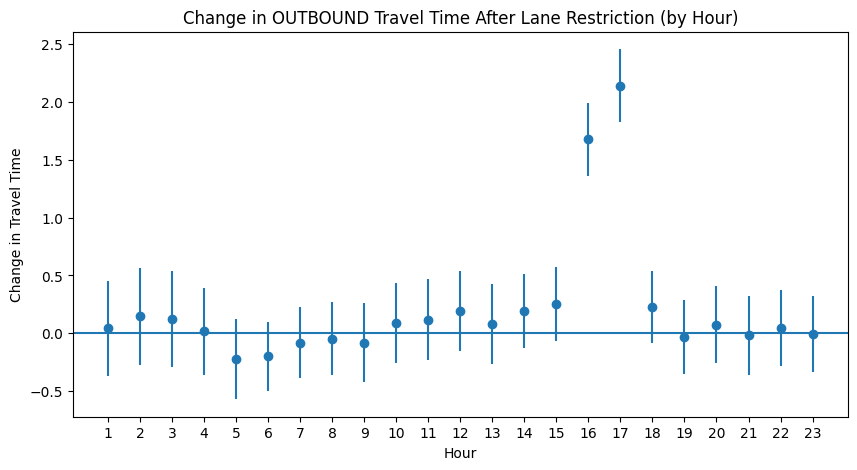

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.axhline(0)

plt.errorbar(
    outbound_hour_effects['hour'],
    outbound_hour_effects['coef'],
    yerr=1.96 * outbound_hour_effects['std_err'],
    fmt='o'
)

plt.title("Change in OUTBOUND Travel Time After Lane Restriction (by Hour)")
plt.xlabel("Hour")
plt.xticks(outbound_hour_effects['hour'])
plt.ylabel("Change in Travel Time")
plt.show()

## Final Interpretation of Outbound Travel Time Increase:

After the lane restriction on Woody Hayes drive, there is a statistically significant increase in travel time in the 1600 and 1700 hours. Visually you can see the confidence intervals do not cross 0 which is key. Everything else is within the range of 0 indicating no effect. 

Outbound travel time for this test is considered the timedelta of the departure of Doan Hall to arrival at Carmack 2. At 4pm and 5pm there is a ~1.6 and ~2.1 minute increase in outbound travel time respectively. There is strong evidence that the observed changes are not due to random variation.

The lane restriction on Woody Hayes Dr. has led to a statistically significant and meaningful increase in the outbound travel times during the afternoon peak of 4-5pm, and has led to minimal impact on the outbound travel during other times of the day.

---


### Inbound Travel Times

Based on the prior testing, I do not expect significant results in terms of travel time increasing for inbound traffic.

Isolating the inbound travel, timedelta of Carmack 2 departure to University Hospital arrival

**Statistical Testing**

`H0`: mean travel time before lane closure = mean travel time after lane closure

`HA`: Mean travel time after > mean travel time before
- This is one sided since we care specifically about increases here due to roadway congestion

In [150]:
# testing the inbound run times to see if there is any significant increase
# can use before_df and after_df for this
# create a df with only CM2 and UH records for inbound analysis
UH_ID = 401
CARMACK_2_ID = 403

before_inbound_df = before_df[(before_df['STOP_ID'] == UH_ID) | (before_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
before_inbound_df = before_inbound_df.drop(columns=['LOAD', 'DEST']) 

# sort by bus and time
before_inbound_df = before_inbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (before_inbound_df['BUS_ID'] == before_inbound_df['BUS_ID'].shift(1))
    & (before_inbound_df['DATE'] == before_inbound_df['DATE'].shift(1))
    & (before_inbound_df['RUN_ID'] == before_inbound_df['RUN_ID'].shift(1))
    & (before_inbound_df['STOP_ID'].shift(1) == CARMACK_2_ID) # only calculate run time if previous record was CARMACK_2
)

before_inbound_df['RUN_TIME'] = np.where(
    same_trip,
    (before_inbound_df['ARRIVAL'] - before_inbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 30 minutes 
before_inbound_df = before_inbound_df[(before_inbound_df['RUN_TIME'] >= 3) & (before_inbound_df['RUN_TIME'] <= 30)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 30 is likely an outlier

display(before_inbound_df.head(3))

#------------------------------
# inbound after lane restriction
after_inbound_df = after_df[(after_df['STOP_ID'] == UH_ID) | (after_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
after_inbound_df = after_inbound_df.drop(columns=['LOAD', 'DEST'])

# sort by bus and time
after_inbound_df = after_inbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (after_inbound_df['BUS_ID'] == after_inbound_df['BUS_ID'].shift(1))
    & (after_inbound_df['DATE'] == after_inbound_df['DATE'].shift(1))
    & (after_inbound_df['RUN_ID'] == after_inbound_df['RUN_ID'].shift(1))
    & (after_inbound_df['STOP_ID'].shift(1) == CARMACK_2_ID) # only calculate run time if previous record was CARMACK_2
)

after_inbound_df['RUN_TIME'] = np.where(
    same_trip,
    (after_inbound_df['ARRIVAL'] - after_inbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 30 minutes
after_inbound_df = after_inbound_df[(after_inbound_df['RUN_TIME'] >= 3) & (after_inbound_df['RUN_TIME'] <= 30)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 30 is likely an outlier

display(after_inbound_df.head(3))

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
1,2104,2026-02-25,21189,401,1.0,13.0,1501.0,1900-01-01 05:03:47,1900-01-01 05:04:21,0 days 00:00:34,5,3,OB,2026-02-25 05:03:47,7.466667
3,2104,2026-02-25,21193,401,0.0,3.0,1501.0,1900-01-01 05:21:46,1900-01-01 05:22:16,0 days 00:00:30,5,21,OB,2026-02-25 05:21:46,7.183333
5,2104,2026-02-25,21197,401,0.0,15.0,1501.0,1900-01-01 05:42:20,1900-01-01 05:43:03,0 days 00:00:43,5,42,OB,2026-02-25 05:42:20,6.850000


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
2,2501,2026-03-27,26679,401,0.0,9.0,1501.0,1900-01-01 05:07:32,1900-01-01 05:08:04,0 days 00:00:32,5,7,OB,2026-03-27 05:07:32,7.766667
4,2501,2026-03-27,26683,401,0.0,4.0,1501.0,1900-01-01 05:21:11,1900-01-01 05:21:46,0 days 00:00:35,5,21,OB,2026-03-27 05:21:11,6.333333
6,2501,2026-03-27,26687,401,0.0,11.0,1501.0,1900-01-01 05:41:21,1900-01-01 05:41:54,0 days 00:00:33,5,41,OB,2026-03-27 05:41:21,7.433333


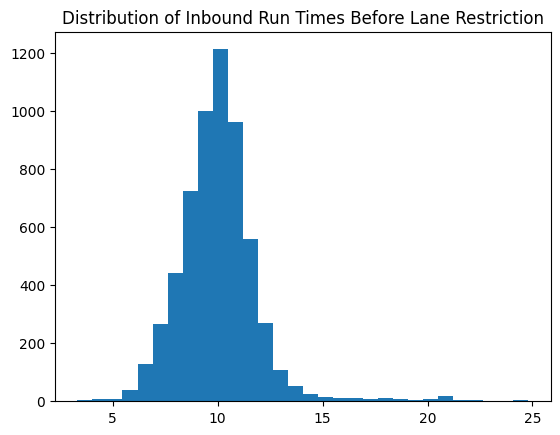

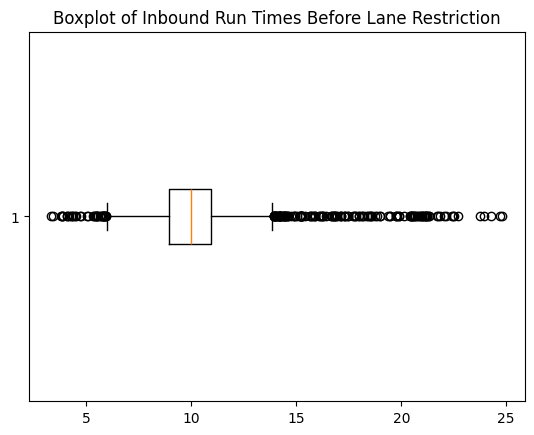

In [151]:
# plot the dist of inbound run times to see if there is any significant skew that would impact the mean
plt.hist(before_inbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Inbound Run Times Before Lane Restriction')
plt.show()

plt.boxplot(before_inbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Inbound Run Times Before Lane Restriction')
plt.show()

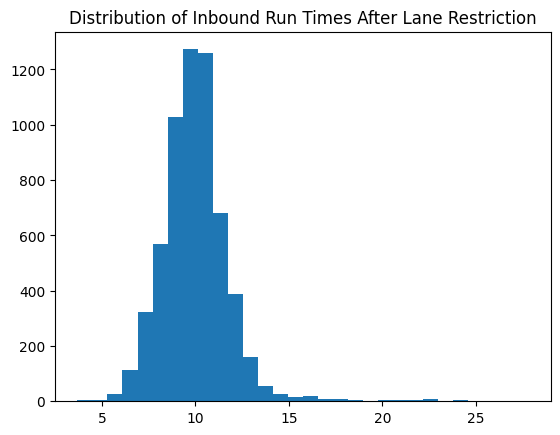

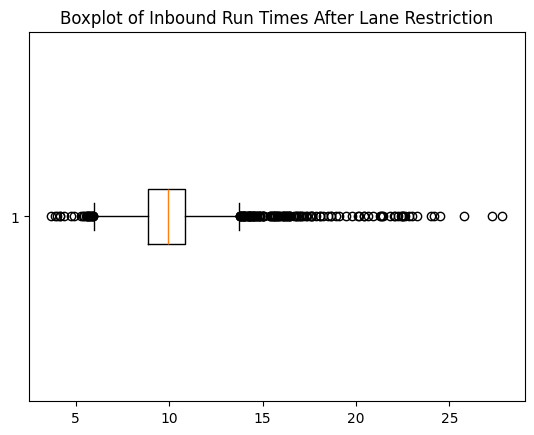

In [152]:
# AFTER
plt.hist(after_inbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Inbound Run Times After Lane Restriction')
plt.show()

plt.boxplot(after_inbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Inbound Run Times After Lane Restriction')
plt.show()

In [153]:
# Inbound regression analysis
# combine before and after data for regression analysis
inbound_df = pd.concat([before_inbound_df, after_inbound_df], ignore_index=True)
inbound_df['post_period'] = (inbound_df['DATE'] >= '2026-03-26').astype(int) # binary variable for before/after lane restriction

inbound_model = smf.ols(
formula='RUN_TIME ~ post_period + C(HOUR) + post_period:C(HOUR)',
data=inbound_df
).fit()

print(inbound_model.summary())

                            OLS Regression Results                            
Dep. Variable:               RUN_TIME   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     83.73
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:53:59   Log-Likelihood:                -22987.
No. Observations:               11927   AIC:                         4.607e+04
Df Residuals:                   11879   BIC:                         4.643e+04
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [154]:
results = inbound_model.summary2().tables[1].reset_index()
results.columns = ['term', 'coef', 'std_err', 't', 'p_value', 'ci_low', 'ci_high']

# Filter only interaction terms
inbound_hour_effects = results[results['term'].str.contains('post_period:C\\(HOUR\\)')]

# Extract hour number
inbound_hour_effects['hour'] = inbound_hour_effects['term'].str.extract(r'T\.(\d+)').astype(int)

# Sort by hour
inbound_hour_effects = inbound_hour_effects.sort_values('hour')

# get rid of sci notattion, but keep very small p-values as <0.000001
inbound_hour_effects['p_value'] = inbound_hour_effects['p_value'].apply(lambda x: f"{x:.6f}" if x > 1e-6 else "<0.000001")

print(inbound_hour_effects[['hour', 'coef', 'p_value']])

    hour      coef   p_value
25     1  0.121446  0.746299
26     2  0.019826  0.957880
27     3  0.213906  0.570297
28     4  0.377024  0.249122
29     5  0.050620  0.865342
30     6 -0.188379  0.480580
31     7  0.009913  0.970841
32     8 -0.398177  0.160234
33     9 -0.217290  0.475699
34    10 -0.240948  0.436105
35    11 -0.092162  0.768667
36    12 -0.221306  0.482222
37    13 -0.348286  0.266629
38    14 -0.143522  0.614722
39    15 -0.141088  0.618205
40    16 -0.145703  0.608127
41    17  0.380459  0.179820
42    18 -0.087777  0.756322
43    19 -0.125530  0.657132
44    20  0.138414  0.654453
45    21  0.065449  0.832015
46    22  0.114985  0.697797
47    23  0.074569  0.801414


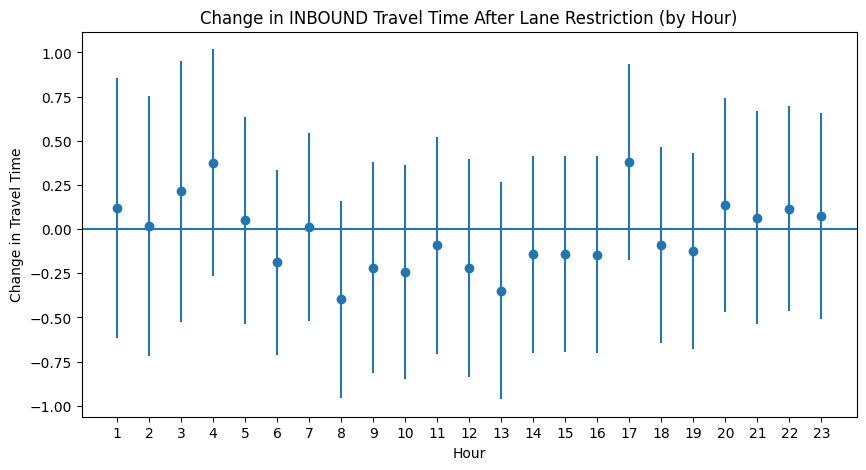

In [155]:
plt.figure(figsize=(10,5))
plt.axhline(0)

plt.errorbar(
    inbound_hour_effects['hour'],
    inbound_hour_effects['coef'],
    yerr=1.96 * inbound_hour_effects['std_err'],
    fmt='o'
)

plt.title("Change in INBOUND Travel Time After Lane Restriction (by Hour)")
plt.xlabel("Hour")
plt.xticks(inbound_hour_effects['hour'])
plt.ylabel("Change in Travel Time")
plt.show()

## Final Interpretation of Inbound Travel Time Increase:

After the lane restriction on Woody Hayes drive, there is no statistically significant increase for inbound travel time at any hour.

Inbound travel time for this test is considered the timedelta of the departure of Carmack 2 to arrival at University Hospital. There is not enough evidence that the observed changes are not due to random variation.

The lane restriction on Woody Hayes Dr. has **NOT** led to a statistically significant and meaningful increase in the inbound travel times.

---


# **Travel Time Impact**

After the lane restriction on Woody Hayes Dr. there has been a statistically significant increase in travel times in the outbound direction in the hours of 4pm and 5pm. There is not enough evidence to conclude that any meaningful changes in travel time have occured at other outbound travel times, or any inbound travel times.

Potential causes:
- Lefthand turn on outbound route likely takes longer
- Inbound traffic lighter

---


### 2) Are buses 'bunching' due to traffic in the area and when is this occuring?

The idea is that busses may be bunching together 

This will be defined by close arrival times of multiple busses at a single stop, or rather how spread out the busses appear to be in terms of arrival time.

**Statistical Testing**

`H0`: The variance of headways did not change after the lane closure

`HA`: The variance of headways changed after the lane closure

**Defining 'bunching':** Theoretically each bus should stop at any given stop at a slice of each hour with a consistent interval inbetween busses stopping.

Assume each bus can stop at each stop 3x per hour, if there is 3 busses running, we would expect a bus to stop at any given stop every ~6.5 minutes. The potential issue here is that 


In [ ]:
# df: contains entire busstate data from feb, mar,  apr
# before_df: busstate data from 2/25 - 3/25
# after_df: busstate data from 3/27 - 4/24

# sort by date and arrival for chronological view
sorted_before_df = before_df.sort_values(['DATE', 'ARRIVAL'], inplace=False)

# split into 2 stops of interest, UH and Carmack 2 as they are the first stops after the construction zone
sorted_before_df_uh = sorted_before_df[sorted_before_df['STOP_ID'] == UH_ID]
# sorted_before_df_cm2 = sorted_before_df[sorted_before_df['STOP_ID'] == CARMACK_2_ID]

sorted_before_df_uh['HEADWAY'] = sorted_before_df_uh['ARRIVAL'].diff().dt.total_seconds() / 60

sorted_before_df_uh = sorted_before_df_uh[(sorted_before_df_uh['HEADWAY'] <= 60) & (sorted_before_df_uh['HEADWAY'] > 0)] # filter out any headways over 60 minutes or na
sorted_before_df_uh = sorted_before_df_uh.dropna(subset=['HEADWAY'])
# remove any na

In [31]:
sorted_after_df = after_df.sort_values(['DATE', 'ARRIVAL'], inplace=False)
sorted_after_df_uh = sorted_after_df[sorted_after_df['STOP_ID'] == UH_ID]
sorted_after_df_uh['HEADWAY'] = sorted_after_df_uh['ARRIVAL'].diff().dt.total_seconds() / 60
sorted_after_df_uh = sorted_after_df_uh[(sorted_after_df_uh['HEADWAY'] <= 60) & (sorted_after_df_uh['HEADWAY'] > 0)] # filter out any headways over 60 minutes or na
sorted_after_df_uh = sorted_after_df_uh.dropna(subset=['HEADWAY'])

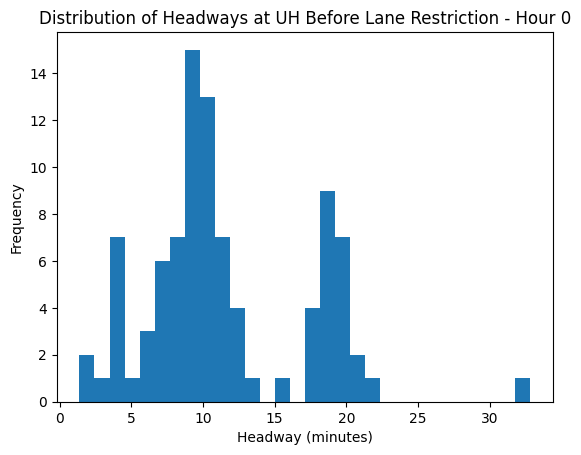

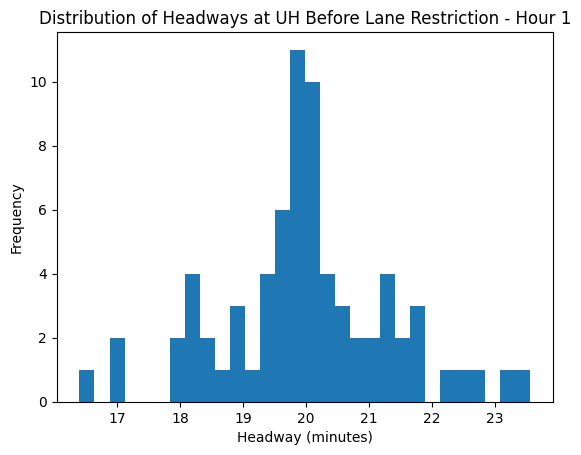

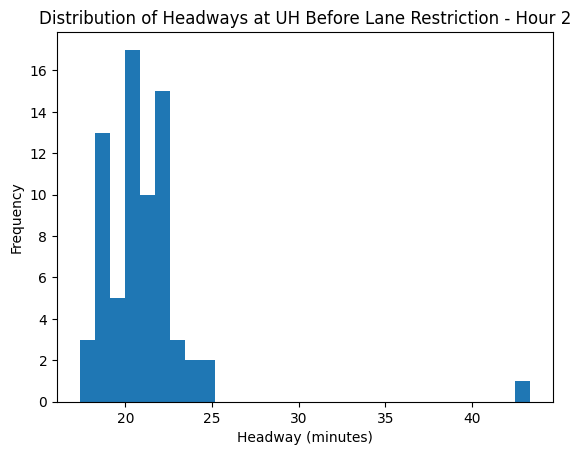

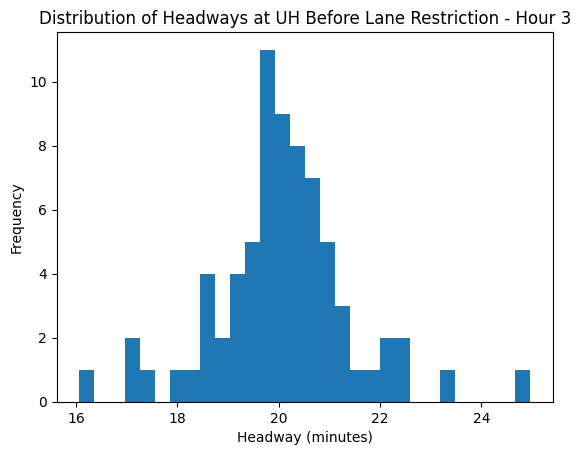

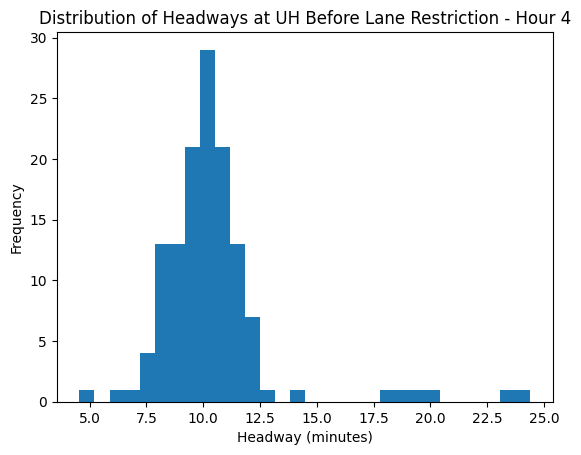

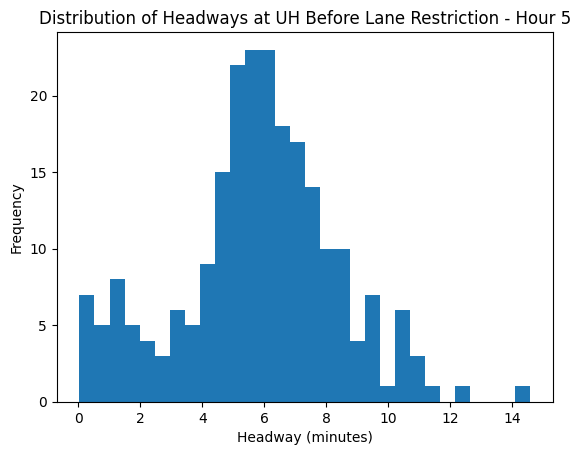

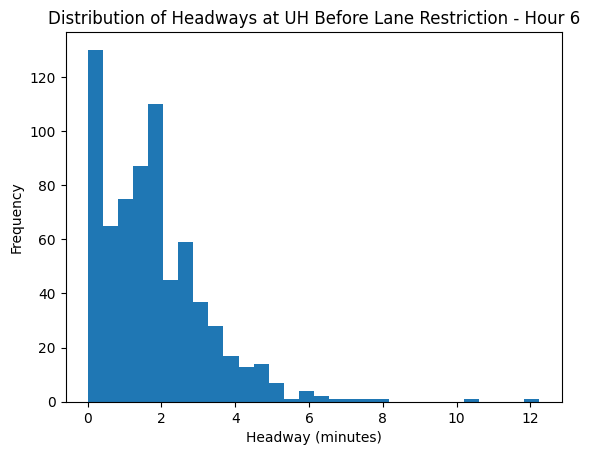

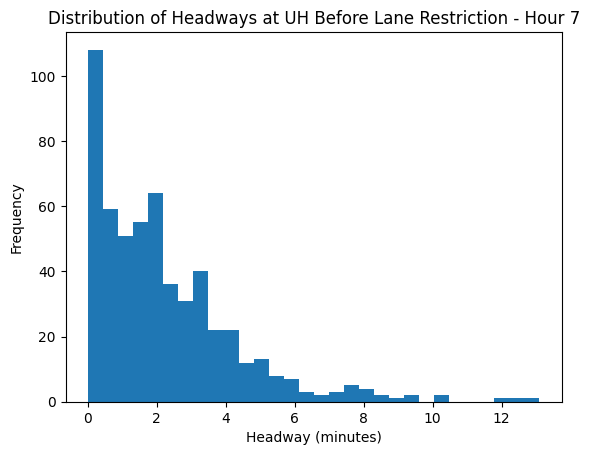

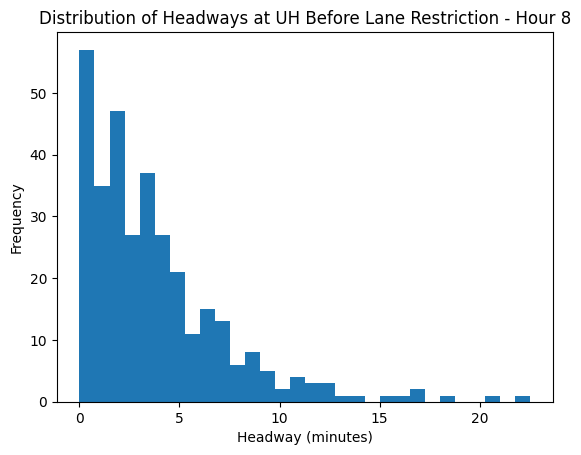

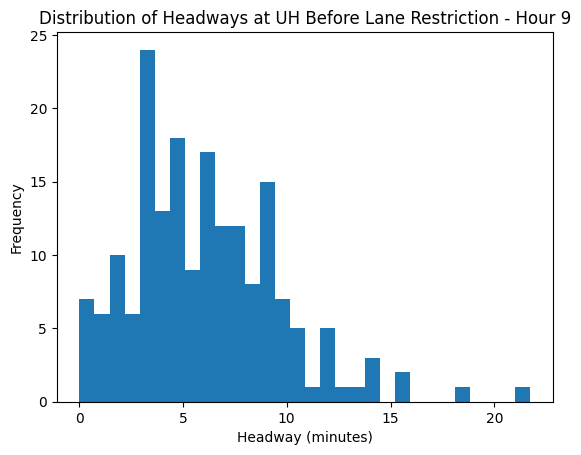

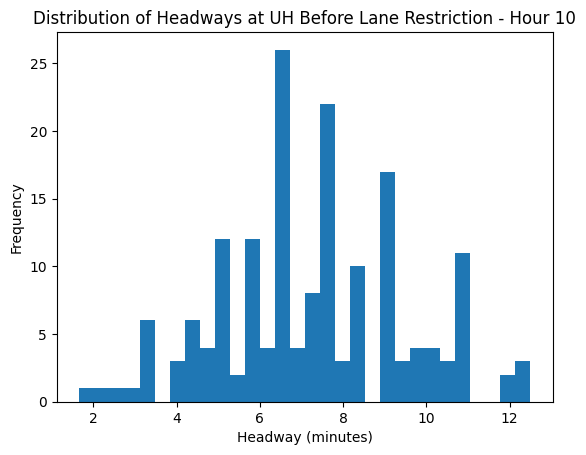

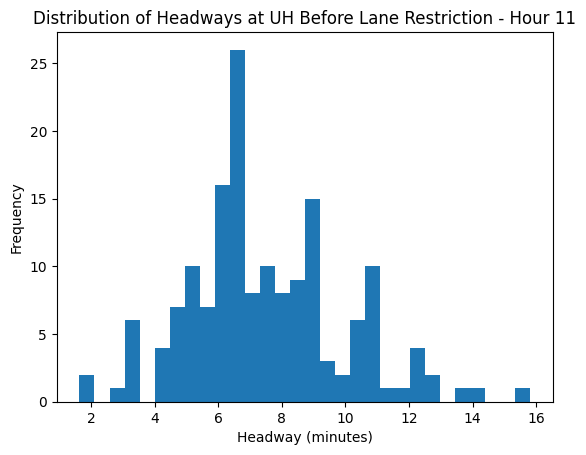

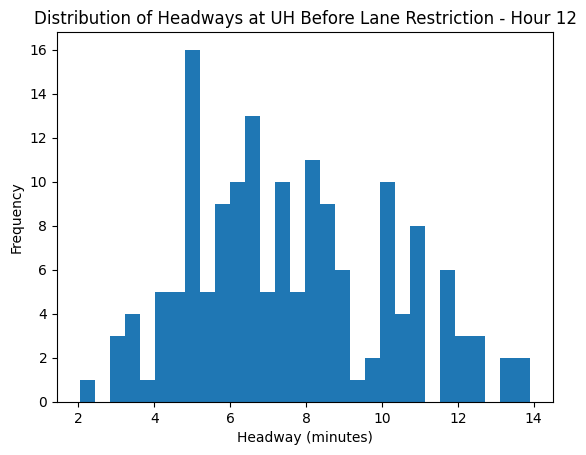

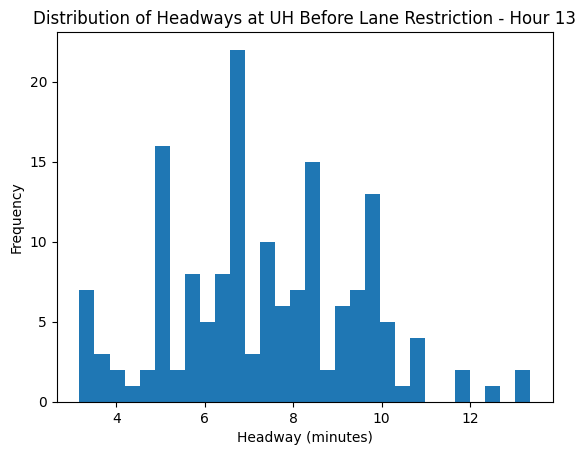

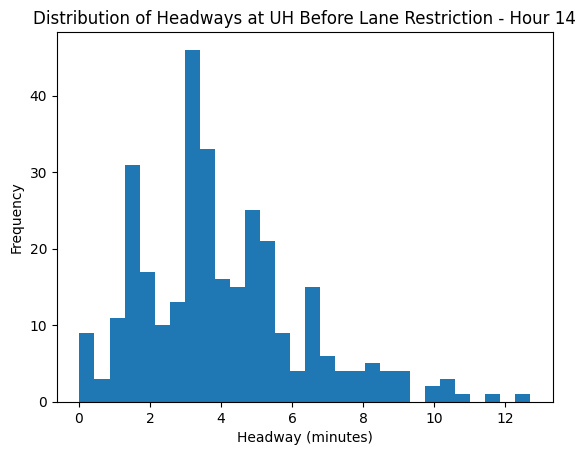

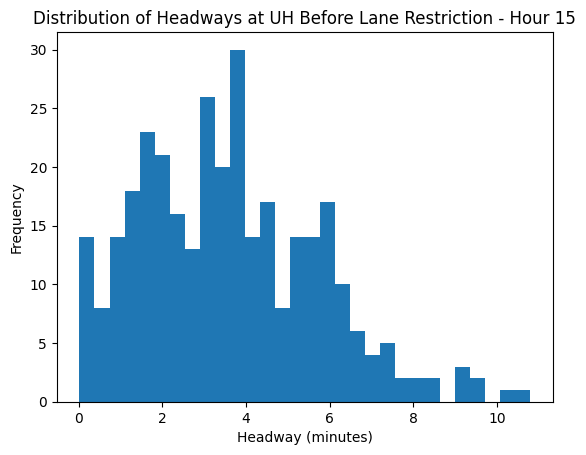

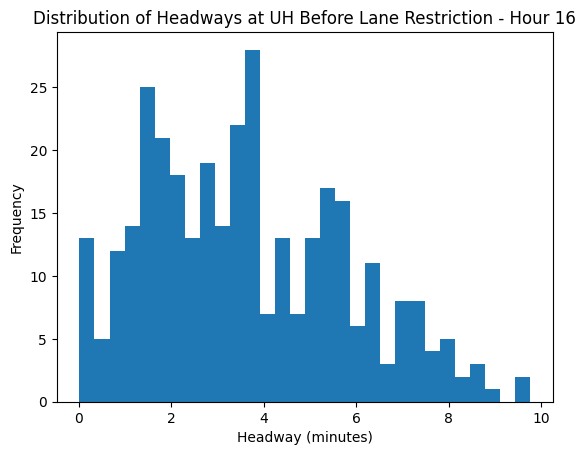

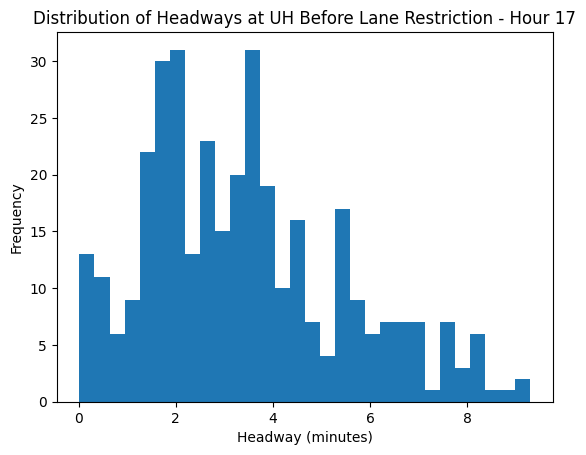

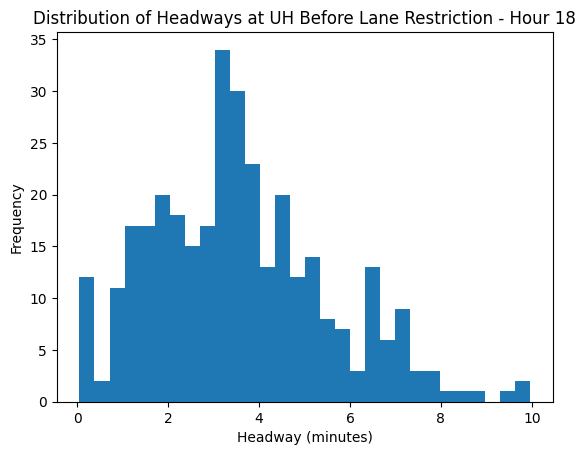

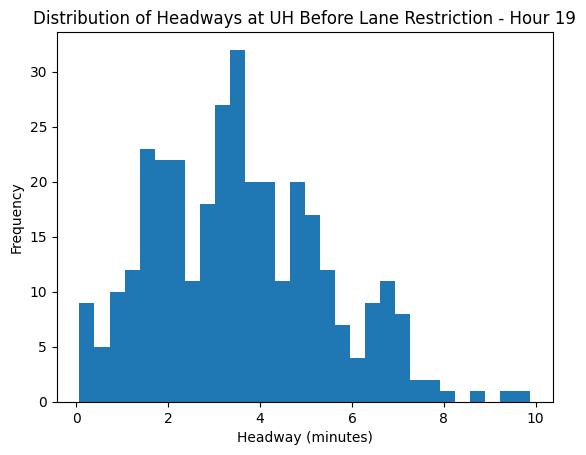

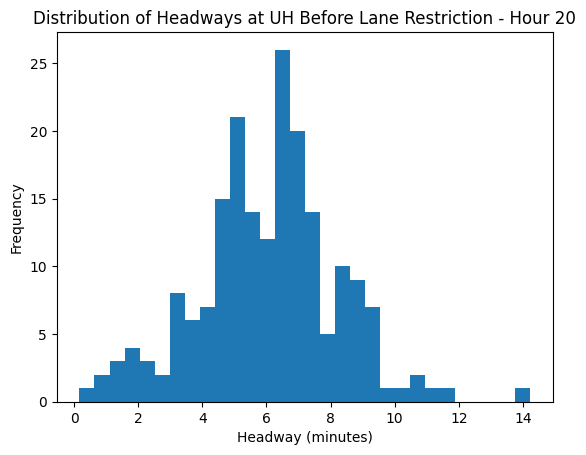

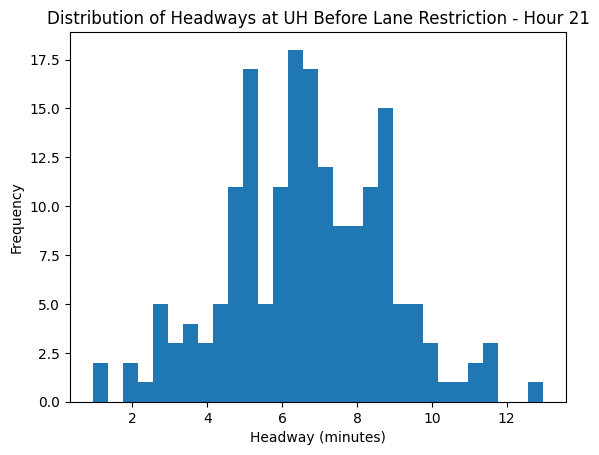

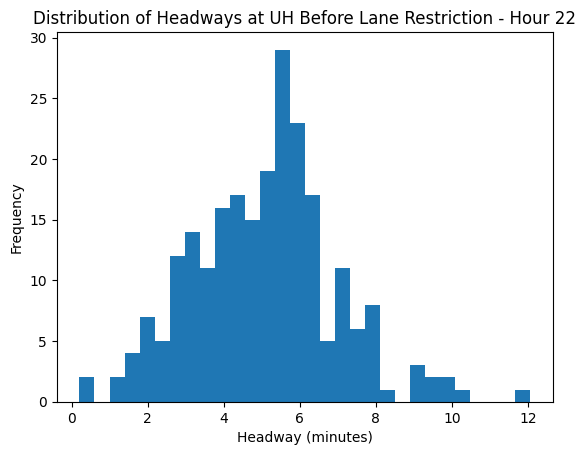

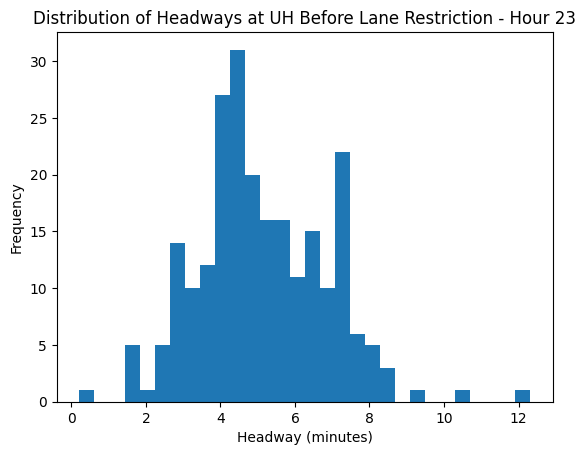

In [28]:
# plot headways for each hour
for hour in sorted_before_df_uh['HOUR'].unique():
    hourly_headways = sorted_before_df_uh[sorted_before_df_uh['HOUR'] == hour]['HEADWAY']
    plt.hist(hourly_headways, bins=30)
    plt.title(f'Distribution of Headways at UH Before Lane Restriction - Hour {hour}')
    plt.xlabel('Headway (minutes)')
    plt.ylabel('Frequency')
    plt.show()

Text(0.5, 1.0, 'Distribution of Headways at UH Before Lane Restriction - All Hours')

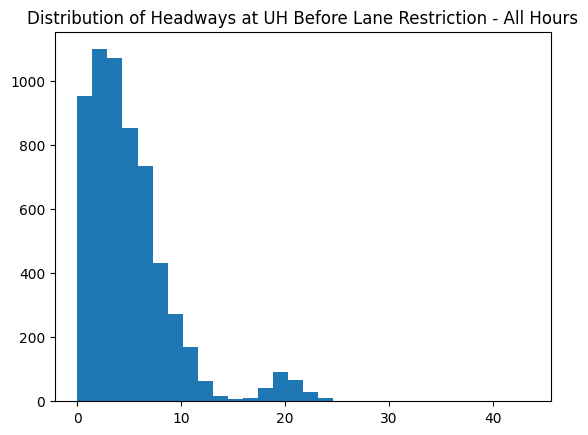

In [29]:
# all headways plotted
plt.hist(sorted_before_df_uh['HEADWAY'], bins=30)
plt.title('Distribution of Headways at UH Before Lane Restriction - All Hours')

### **Levene's Test:**

This test will determine if two groups have equal variance,

How far away are headways from their mean?
- If bunching is occuring I am assuming that headways would look something like [1, 0.8, 2, 12, 2, 1.2] etc 
    - **HIGH VARIANCE**
- If bunching is *NOT* occuring I am assuming that headways will be much more consistent [5, 6, 5.5, 6, 5, 6] etc 
    - **LOW VARIANCE**

To account for differing headways at different times of the day, a coefficient of variation will be used (= std/mean)
- A low CV <0.5 would indicate regular service
- CV ~ 1 would indicate irregularity in terms of arrival times
- CV > 1 would indicate strong bunching

CV in this case will scale with the mean of any given hour, allowing the differences to be captured

In [32]:
from scipy.stats import levene

stat, p = levene(sorted_before_df_uh['HEADWAY'], sorted_after_df_uh['HEADWAY'])

print("Levene stat:", stat)
print("p-value:", p)

Levene stat: 0.23391453628516312
p-value: 0.6286452093393008


In [33]:
def cv(x):
    return x.std() / x.mean()

cv_before = cv(sorted_before_df_uh['HEADWAY'])
cv_after = cv(sorted_after_df_uh['HEADWAY'])

print("CV before:", cv_before)
print("CV after:", cv_after)

CV before: 0.8611847975081658
CV after: 0.8738355193618736


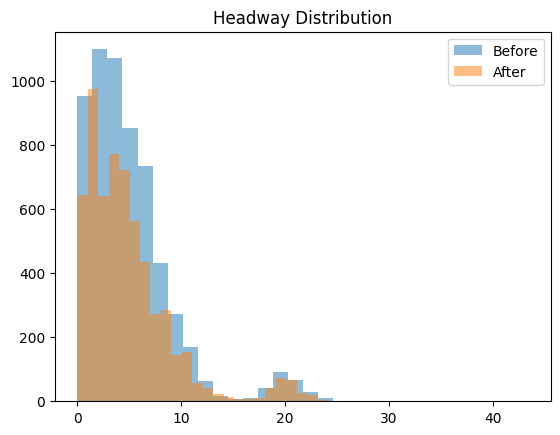

In [ ]:
plt.hist(sorted_before_df_uh['HEADWAY'], bins=30, alpha=0.5, label='Before')
plt.hist(sorted_after_df_uh['HEADWAY'], bins=30, alpha=0.5, label='After')
plt.legend()
plt.title("Headway Distribution at UH Before vs After Lane Restriction")
plt.show()

When we are not accounting for the time of day, there is no statistical evidence that the headways at UH have changed after the lane restriction on Woody Hayes Dr.

In [40]:
results = []

for hour in sorted_before_df_uh['HOUR'].unique():
    before = sorted_before_df_uh[sorted_before_df_uh['HOUR'] == hour]['HEADWAY']
    after = sorted_after_df_uh[sorted_after_df_uh['HOUR'] == hour]['HEADWAY']
    
    if len(before) > 5 and len(after) > 5:  # avoid tiny samples
        stat, p = levene(before, after)
        
        results.append({
            'hour': hour,
            'p_value': p,
            'mean_before': before.mean(),
            'mean_after': after.mean(),
            'std_before': before.std(),
            'std_after': after.std(),
            'var_before': before.var(),
            'var_after': after.var(),
            'cv_before': before.std() / before.mean(),
            'cv_after': after.std() / after.mean()
        })

results_df = pd.DataFrame(results)

In [41]:
results_df

,hour,p_value,mean_before,mean_after,std_before,std_after,var_before,var_after,cv_before,cv_after
0,0,0.622353,11.485870,11.106734,5.699115,5.882033,32.479908,34.598316,0.496185,0.529592
1,1,0.269269,19.999537,19.815509,1.373600,1.097106,1.886776,1.203641,0.068682,0.055366
2,2,0.561710,21.010329,20.791898,3.147035,1.801447,9.903828,3.245211,0.149785,0.086642
3,3,0.653994,20.081019,20.078009,1.382000,1.354156,1.909924,1.833739,0.068821,0.067445
4,4,0.562139,10.430051,10.676744,2.701467,2.932776,7.297924,8.601174,0.259008,0.274688
5,5,0.741304,5.794591,5.635931,2.580355,2.593047,6.658233,6.723892,0.445304,0.460092
6,6,0.004360,1.793405,1.687658,1.444465,1.212864,2.086480,1.471039,0.805432,0.718667
7,7,0.498824,2.221441,2.189603,2.060412,1.869911,4.245298,3.496566,0.927511,0.853995
8,8,0.092798,3.796465,3.719333,3.612996,3.063951,13.053743,9.387795,0.951674,0.823790
9,9,0.740395,6.110507,5.665625,3.604033,3.703025,12.989057,13.712393,0.589809,0.653595


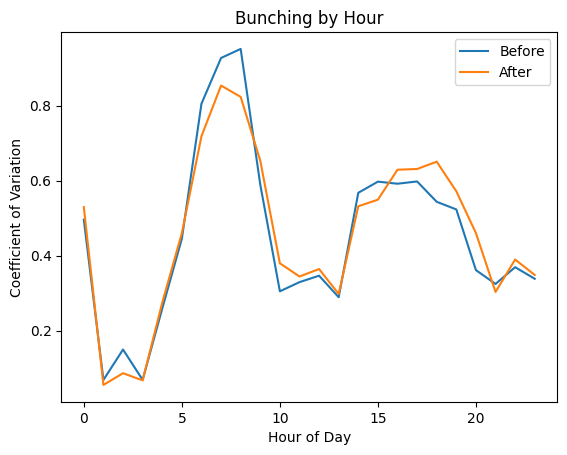

In [39]:
before_cv = (
    sorted_before_df_uh.groupby(['HOUR', ])['HEADWAY']
    .agg(['mean', 'std', 'var', 'count'])
    .reset_index()
)
before_cv['cv'] = before_cv['std'] / before_cv['mean']

after_cv = (
    sorted_after_df_uh.groupby(['HOUR', ])['HEADWAY']
    .agg(['mean', 'std', 'var', 'count'])
    .reset_index()
)
after_cv['cv'] = after_cv['std'] / after_cv['mean']

plt.plot(before_cv['HOUR'], before_cv['cv'], label='Before')
plt.plot(after_cv['HOUR'], after_cv['cv'], label='After')

plt.xlabel('Hour of Day')
plt.ylabel('Coefficient of Variation')
plt.title('Bunching by Hour')
plt.legend()
plt.show()

### **Interpretation:**

The variance in headway for arrival at the University Hospital stop was analyzed 

A p-value < 0.05 indicates a statistically significant change in variability:
- 6am: Variance *decreased* -> service got more consistent after the lane changes
- 10am: Variance *increased*
- 3pm: Variance *decreased* -> service got more consistent after the lane changes
- 6pm: Variance *increased*
- 8pm: Variance *increased*

Service being more consistent in the 6am and 3pm hour could be due to a variety of factors.

